In [ ]:
!pip install -U tensorflow keras


## Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
import os

from sklearn.model_selection import train_test_split

os.environ["KERAS_BACKEND"] = "tensorflow"
keras.utils.set_random_seed(42)

In [ ]:
# Not needed because we are using a public RoBERTa model
# from huggingface_hub import login
# from google.colab import userdata

# HF_TOKEN = userdata.get('HF_TOKEN') # Access the saved secret
# if HF_TOKEN:
#     login(token=HF_TOKEN)
#     print("Successfully logged in to Hugging Face!")
# else:
#     print("HF_TOKEN not set in Colab secrets.")

## Load Dataset

In [ ]:
!pip install --upgrade kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eshummalik/socialbuzz-sentiment-analytics")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'socialbuzz-sentiment-analytics' dataset.
Path to dataset files: /kaggle/input/socialbuzz-sentiment-analytics


In [ ]:
files = os.listdir(path)
print("Files found:", files)

Files found: ['sentimentdataset.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "sentimentdataset.csv"))

print(df.head())

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes     

## Demoji and Tokenize

In [ ]:
!pip install demoji

import demoji

In [ ]:
df['cleaned_text'] = df['Text'].apply(lambda x: demoji.replace(x, "")) # without emoji
df['replaced_text'] = df['Text'].apply(lambda x: demoji.replace_with_desc(x)) # textualised emoji
df['Emoji'] =  df['Text'].apply(lambda x: list(demoji.findall(x).values()))

## df['Likes'].min() -> 10.0, df['Likes'].max() -> 80.0
df['Likes'] = df['Likes'].apply(lambda x: 'High' if x > 59 else 'Low')

df = df[['Likes', 'cleaned_text', 'replaced_text', 'Emoji']]

df.head()

,Likes,cleaned_text,replaced_text,Emoji
0,Low,Enjoying a beautiful day at the park! ...,Enjoying a beautiful day at the park! ...,[]
1,Low,Traffic was terrible this morning. ...,Traffic was terrible this morning. ...,[]
2,Low,Just finished an amazing workout! ...,Just finished an amazing workout! :flexed bic...,[flexed biceps]
3,Low,Excited about the upcoming weekend getaway! ...,Excited about the upcoming weekend getaway! ...,[]
4,Low,Trying out a new recipe for dinner tonight. ...,Trying out a new recipe for dinner tonight. ...,[]


In [ ]:
df.shape

(732, 4)

## Load the model and tokenizer

In [ ]:
!pip install transformers==4.40.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.6.0
    Uninstalling huggingface_hub-1.6.0:
      Successfully uninstalled huggingface_hub-1.6.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follow

In [ ]:
from transformers import AutoTokenizer, AutoConfig
from transformers import TFRobertaModel

MODEL = f"cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)

backbone = TFRobertaModel.from_pretrained(MODEL)
backbone.count_params()

All model checkpoint layers were used when initializing TFRobertaModel.

All the layers of TFRobertaModel were initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


124645632

In [ ]:
def preprocess(text):
    new_text = []
    for t in str(text).split(" "): # Added str() just in case of NaNs
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

df['cleaned_text'] = df['cleaned_text'].apply(preprocess)
df['replaced_text'] = df['replaced_text'].apply(preprocess)

# Tokenize 'cleaned_text' and store in DF

clean_encodings = tokenizer(df['cleaned_text'].tolist(), padding=True, truncation=True, return_tensors='pt')
df['cleaned_input_ids'] = list(clean_encodings['input_ids'])
df['cleaned_attention_mask'] = list(clean_encodings['attention_mask'])

# Tokenize 'replaced_text' and store in DF
replaced_encodings = tokenizer(df['replaced_text'].tolist(), padding=True, truncation=True, return_tensors='pt')
df['replaced_input_ids'] = list(replaced_encodings['input_ids'])
df['replaced_attention_mask'] = list(replaced_encodings['attention_mask'])

labels = (df["Likes"] == "High").astype(int).values

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
cleaned_df = df[['cleaned_text', 'cleaned_input_ids', 'cleaned_attention_mask', 'Likes']]
replaced_df = df[['replaced_text', 'replaced_input_ids', 'replaced_attention_mask', 'Likes']]

cleaned_df.head()

,cleaned_text,cleaned_input_ids,cleaned_attention_mask,Likes
0,Enjoying a beautiful day at the park! ...,"[tensor(0), tensor(16013), tensor(154), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
1,Traffic was terrible this morning. ...,"[tensor(0), tensor(11830), tensor(21), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
2,Just finished an amazing workout! ...,"[tensor(0), tensor(1801), tensor(1550), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
3,Excited about the upcoming weekend getaway! ...,"[tensor(0), tensor(22847), tensor(4560), tenso...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
4,Trying out a new recipe for dinner tonight. ...,"[tensor(0), tensor(28386), tensor(66), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low


In [ ]:
# Check the actual lengths of tokenized rows

def get_lengths(mask_column):
    lengths = [sum(m) for m in mask_column]
    return max(lengths), sum(lengths)/len(lengths)


max_len, avg_len = get_lengths(df['cleaned_attention_mask'])
print(f"Cleaned max: {max_len}, avg: {avg_len:.2f}")

max_len, avg_len = get_lengths(df['replaced_attention_mask'])
print(f"Replaced max: {max_len}, avg: {avg_len:.2f}")

Cleaned max: 41, avg: 22.75
Replaced max: 41, avg: 22.81


## Split Dataset

In [ ]:
# Statified by "Likes" (binary: 1,0)
labels = (df["Likes"] == "High").astype(int)

# Train set index
train_idx, temp_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Validation set index + Test set index
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=labels[temp_idx],
    random_state=42
)


# cleaned_df dataset
c_train_df = cleaned_df.loc[train_idx]
c_val_df   = cleaned_df.loc[val_idx]
c_test_df  = cleaned_df.loc[test_idx]

# replaced_df dataset
r_train_df = replaced_df.loc[train_idx]
r_val_df   = replaced_df.loc[val_idx]
r_test_df  = replaced_df.loc[test_idx]

# labels
y_train = labels.loc[train_idx].values
y_val   = labels.loc[val_idx].values
y_test  = labels.loc[test_idx].values

In [ ]:
c_train_df.head()

,cleaned_text,cleaned_input_ids,cleaned_attention_mask,Likes
490,Standing before the grandeur of the Eiffel Tow...,"[tensor(0), tensor(45150), tensor(137), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
155,Empowerment through learning a new skill. ...,"[tensor(0), tensor(3676), tensor(11017), tenso...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
341,Curiosity sparked by exploring a mysterious an...,"[tensor(0), tensor(42090), tensor(45226), tens...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
527,"Rocking out at a Guns N' Roses show, the iconi...","[tensor(0), tensor(500), tensor(12088), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
137,The euphoria of a surprise birthday celebrati...,"[tensor(0), tensor(20), tensor(30882), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low


In [ ]:
r_train_df.head()

,replaced_text,replaced_input_ids,replaced_attention_mask,Likes
490,Standing before the grandeur of the Eiffel Tow...,"[tensor(0), tensor(45150), tensor(137), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
155,Empowerment through learning a new skill. ...,"[tensor(0), tensor(3676), tensor(11017), tenso...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
341,Curiosity sparked by exploring a mysterious an...,"[tensor(0), tensor(42090), tensor(45226), tens...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
527,"Rocking out at a Guns N' Roses show, the iconi...","[tensor(0), tensor(500), tensor(12088), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
137,The euphoria of a surprise birthday celebrati...,"[tensor(0), tensor(20), tensor(30882), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low


## Load a Pre-Trained Model

## Finetuning

In [ ]:
# Compute weights to correct imbalanced dataset
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.5909090909090909), np.int64(1): np.float64(3.25)}


In [ ]:
import keras_hub

In [ ]:
!pip install keras_tuner

In [ ]:
class RobertaLayer(keras.layers.Layer):
    def __init__(self, backbone, **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            training=False
        )
        return outputs.last_hidden_state[:, 0, :]

In [ ]:
import keras_tuner as kt

def build_model(hp):
    # Define hyper-parameters
    units    = hp.Choice('units', values=[32, 64, 128])
    dropout  = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    lr       = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])

    backbone.trainable = True

    input_ids      = keras.layers.Input(shape=(41,), dtype=tf.int32, name="input_ids")
    attention_mask = keras.layers.Input(shape=(41,), dtype=tf.int32, name="attention_mask")

    cls_output = RobertaLayer(backbone)([input_ids, attention_mask])

    x   = keras.layers.Dense(units, activation='relu')(cls_output)
    x   = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=[input_ids, attention_mask], outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# GridSearch
tuner_C = kt.GridSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=None,
    directory='my_dir_C',
    project_name='keras_grid_search_C'
)

Reloading Tuner from my_dir_C/keras_grid_search_C/tuner0.json


In [ ]:
### MODEL 1: Without Emoji
# Prepare data for cleaned
x_train_C = {
    "input_ids":      tf.constant([t.numpy() for t in c_train_df["cleaned_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in c_train_df["cleaned_attention_mask"]], dtype=tf.int32)
}
x_val_C = {
    "input_ids":      tf.constant([t.numpy() for t in c_val_df["cleaned_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in c_val_df["cleaned_attention_mask"]], dtype=tf.int32)
}

tuner_C.search(
    x=x_train_C,
    y=y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val_C, y_val),
    class_weight=class_weights
)

# Check best parameters
best_hp = tuner_C.get_best_hyperparameters(1)[0]
print("Best units:", best_hp.get('units'))
print("Best dropout:", best_hp.get('dropout'))
print("Best lr:", best_hp.get('learning_rate'))

Best units: 128
Best dropout: 0.1
Best lr: 1e-05


In [ ]:
# Make the best model
cleaned_best_model = tuner_C.get_best_models(num_models=1)[0]

#fit
historyC = cleaned_best_model.fit(
    x_train_C,
    y_train,
    validation_data=(x_val_C, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)

# Prepare test data
x_test_C = {
    "input_ids":      tf.constant([t.numpy() for t in c_test_df["cleaned_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in c_test_df["cleaned_attention_mask"]], dtype=tf.int32)
}

# Evaluate
loss, accuracy = cleaned_best_model.evaluate(x_test_C, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Estimate
predictions = cleaned_best_model.predict(x_test_C)
pred_labels = (predictions > 0.5).astype(int)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 904ms/step - accuracy: 0.7658 - loss: 0.7520 - val_accuracy: 0.7808 - val_loss: 0.4908
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.7282 - loss: 0.7261 - val_accuracy: 0.7260 - val_loss: 0.5203
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6821 - loss: 0.6818 - val_accuracy: 0.6986 - val_loss: 0.5433
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6359 - loss: 0.6925 - val_accuracy: 0.6438 - val_loss: 0.5597
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6342 - loss: 0.6735 - val_accuracy: 0.6712 - val_loss: 0.5730
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6081 - loss: 0.6088
Test Loss: 0.6088
Test Accuracy: 0.6081
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step


In [ ]:
cleaned_best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roberta_layer       │ (None, 768)       │          0 │ input_ids[0][0],  │
│ (RobertaLayer)      │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ roberta_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 295,685 (1.13 MB)

 Trainable params: 98,561 (385.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 197,124 (770.02 KB)

**Note: The parameter count in model.summary() may show 0 for the backbone layer.
This is a known limitation of Keras 3.x, which cannot track weights of external TF models.
However, the backbone weights are still included in training and will be updated normally.

In [ ]:
### MODEL 2: Without Emoji
import keras_tuner as kt
# GridSearch
tuner_R = kt.GridSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=None,
    directory='my_dir_R',
    project_name='keras_grid_search_R'
)

# Prepare data for cleaned
x_train_R = {
    "input_ids":      tf.constant([t.numpy() for t in r_train_df["replaced_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in r_train_df["replaced_attention_mask"]], dtype=tf.int32)
}
x_val_R = {
    "input_ids":      tf.constant([t.numpy() for t in r_val_df["replaced_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in r_val_df["replaced_attention_mask"]], dtype=tf.int32)
}

tuner_R.search(
    x=x_train_R,
    y=y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val_R, y_val),
    class_weight=class_weights
)

# Check best parameters
best_hp = tuner_R.get_best_hyperparameters(1)[0]
print("Best units:", best_hp.get('units'))
print("Best dropout:", best_hp.get('dropout'))
print("Best lr:", best_hp.get('learning_rate'))

Reloading Tuner from my_dir_R/keras_grid_search_R/tuner0.json
Best units: 32
Best dropout: 0.3
Best lr: 0.001


In [ ]:
# Make the best model
replaced_best_model = tuner_R.get_best_models(num_models=1)[0]

# Prepare test data
x_test_R = {
    "input_ids":      tf.constant([t.numpy() for t in r_test_df["replaced_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in r_test_df["replaced_attention_mask"]], dtype=tf.int32)
}

#fit
historyR = replaced_best_model.fit(
    x_train_R,
    y_train,
    validation_data=(x_val_R, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)

# Evaluate
loss, accuracy = replaced_best_model.evaluate(x_test_R, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Estimate
predictions = replaced_best_model.predict(x_test_R)
pred_labels = (predictions > 0.5).astype(int)

Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 876ms/step - accuracy: 0.5265 - loss: 0.7838 - val_accuracy: 0.5205 - val_loss: 0.6485
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6564 - loss: 0.6355 - val_accuracy: 0.7397 - val_loss: 0.5245
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6479 - loss: 0.6519 - val_accuracy: 0.5205 - val_loss: 0.6153
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6000 - loss: 0.6316 - val_accuracy: 0.6164 - val_loss: 0.5573
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.6068 - loss: 0.6173 - val_accuracy: 0.5753 - val_loss: 0.5857
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.5676 - loss: 0.6377
Test Loss: 0.6377
Test Accuracy: 0.5676
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step


In [ ]:
replaced_best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roberta_layer       │ (None, 768)       │          0 │ input_ids[0][0],  │
│ (RobertaLayer)      │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │     24,608 │ roberta_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,925 (288.77 KB)

 Trainable params: 24,641 (96.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 49,284 (192.52 KB)

**Note: The parameter count in model.summary() may show 0 for the backbone layer.
This is a known limitation of Keras 3.x, which cannot track weights of external TF models.
However, the backbone weights are still included in training and will be updated normally.

Loss Curve

In [ ]:
# Function for plotting loss curve

def plot_loss(history, title):

    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(train_loss)+1)

    plt.figure()

    plt.plot(epochs, train_loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Cross Entropy Loss")

    plt.legend()
    plt.show()

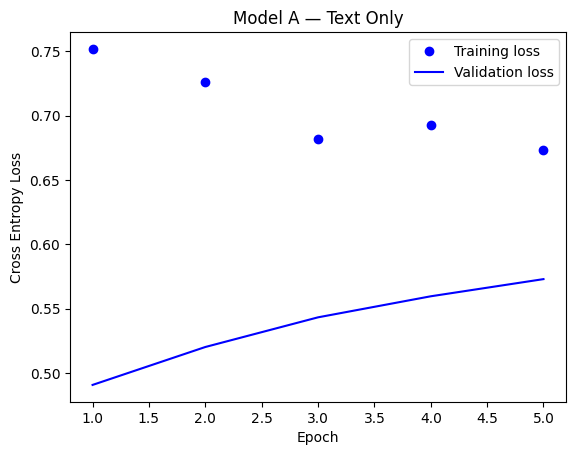

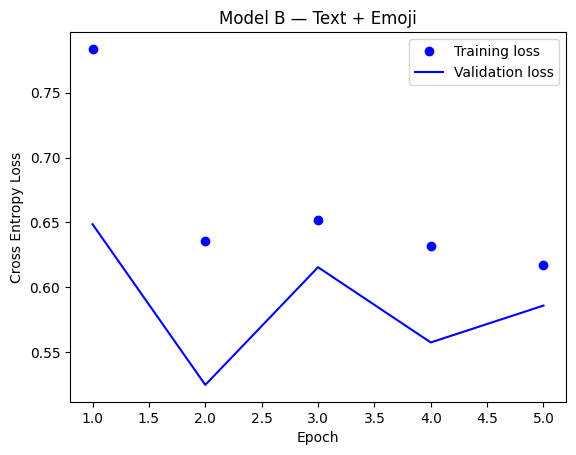

In [ ]:
plot_loss(historyC, "Model A — Text Only")
plot_loss(historyR, "Model B — Text + Emoji")

## Predictions

In [ ]:
# predict
y_prob_C = cleaned_best_model.predict(x_test_C)
y_pred_C = (y_prob_C > 0.5).astype(int)

# evaluate
cleaned_best_model.evaluate(x_train_C, y_train)
cleaned_best_model.evaluate(x_test_C, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6068 - loss: 0.5957
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6081 - loss: 0.6088


[0.6087885499000549, 0.6081081032752991]

In [ ]:
# predict
y_prob_R = replaced_best_model.predict(x_test_R)
y_pred_R = (y_prob_R > 0.5).astype(int)

# evaluate
replaced_best_model.evaluate(x_train_R, y_train)
replaced_best_model.evaluate(x_test_R, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.6051 - loss: 0.5821
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5676 - loss: 0.6377


[0.6376599669456482, 0.5675675868988037]

## Evaluation metrics

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

f1_C = f1_score(y_test, y_pred_C)
roc_C = roc_auc_score(y_test, y_prob_C)

print("Cleaned Model")
print("F1-score:", f1_C)
print("ROC-AUC:", roc_C)

print("\nClassification Report")
print(classification_report(y_test, y_pred_C, target_names=["Low", "High"]))

Cleaned Model
F1-score: 0.2926829268292683
ROC-AUC: 0.6551226551226551

Classification Report
              precision    recall  f1-score   support

         Low       0.89      0.62      0.73        63
        High       0.20      0.55      0.29        11

    accuracy                           0.61        74
   macro avg       0.54      0.58      0.51        74
weighted avg       0.78      0.61      0.66        74



In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

f1_R = f1_score(y_test, y_pred_R)
roc_R = roc_auc_score(y_test, y_prob_R)

print("Cleaned Model") # should be Replaced Model
print("F1-score:", f1_R)
print("ROC-AUC:", roc_R)

print("\nClassification Report")
# correct: y_pred_R
print(classification_report(y_test, y_pred_R, target_names=["Low", "High"]))

Cleaned Model
F1-score: 0.2727272727272727
ROC-AUC: 0.6060606060606061

Classification Report
              precision    recall  f1-score   support

         Low       0.88      0.57      0.69        63
        High       0.18      0.55      0.27        11

    accuracy                           0.57        74
   macro avg       0.53      0.56      0.48        74
weighted avg       0.77      0.57      0.63        74



In [ ]:
results = pd.DataFrame({

    "Model": ["Text Only", "Text + Emoji"],

    "F1 Score": [f1_C, f1_R],

    "ROC-AUC": [roc_C, roc_R]

})

results

,Model,F1 Score,ROC-AUC
0,Text Only,0.292683,0.655123
1,Text + Emoji,0.272727,0.606061


## Confusion Matrix

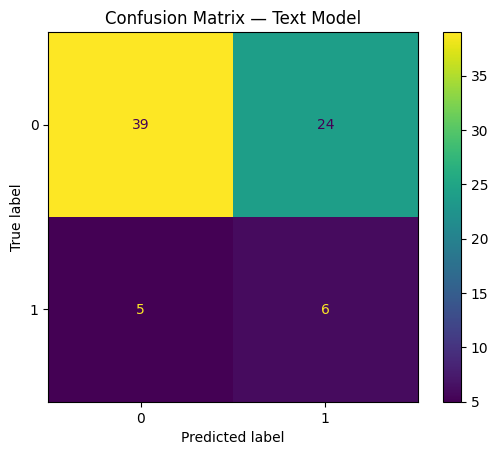

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_C
)

plt.title("Confusion Matrix — Text Model")
plt.show()

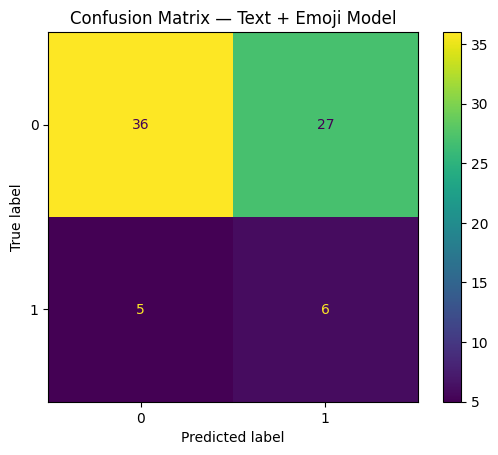

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_R
)

plt.title("Confusion Matrix — Text + Emoji Model")
plt.show()

## SHAP explanation

In [ ]:
import shap

def predict_fn(texts):
    encoded = tokenizer(
        list(texts),
        max_length=41,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    probs = cleaned_best_model.predict({
        "input_ids":      encoded["input_ids"],
        "attention_mask": encoded["attention_mask"]
    })
    return probs  # shape (N, 1)

explainer_C = shap.Explainer(
    predict_fn,
    shap.maskers.Text(tokenizer)  # tokenizer 넘겨야 텍스트 마스킹 제대로 돼요
)

# train 텍스트 원본으로 넘기기
shap_values_C = explainer_C(list(c_train_df["cleaned_text"])[:20])

shap.plots.text(shap_values_C[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━

...

PartitionExplainer explainer: 100%|██████████| 20/20 [03:22<00:00, 10.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━

  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer: 21it [03:33, 10.66s/it]


In [ ]:
def predict_fn_replaced(texts):
    encoded = tokenizer(
        list(texts),
        max_length=41,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    probs = replaced_best_model.predict({
        "input_ids":      encoded["input_ids"],
        "attention_mask": encoded["attention_mask"]
    })
    return probs

explainer_R = shap.Explainer(
    predict_fn_replaced,
    shap.maskers.Text(tokenizer)
)

shap_values_R = explainer_R(list(r_train_df["replaced_text"])[:20])

shap.plots.text(shap_values_R[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━

...

PartitionExplainer explainer: 100%|██████████| 20/20 [03:18<00:00, 10.18s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━

  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer: 21it [03:28, 10.44s/it]
